## Step 1: Data Collection
Data is retrieved from WRDS Compustat Global database (comp_global_daily.g_funda), 
which contains annual financial statements for listed companies worldwide.
The three companies selected are Kweichow Moutai, Wuliangye, and Haitian Flavouring — 
leading consumer sector companies listed on the A-share market.

In [3]:
import wrds
db=wrds.Connection()

Enter your WRDS username [zzh]:zhenghaozhang
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
Loading library list...
Done


In [4]:
# 测试连接，看看WRDS里有哪些数据库
db.list_libraries()

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all',
 'boardex_trial',
 'boardsmp',
 'bvd',
 'bvd_amadeus_trial',
 'bvd_bvdbankf',
 'bvd_bvdbankf_trial',
 'bvd_orbis_trial',
 'bvdsamp',
 'calcbench_trial',
 'calcbnch',
 'candid_samp',
 'cboe',
 'cboe_all',
 'cboe_sample',
 'cboesamp',
 'cddsamp',
 'ciq',
 'ciq_capstrct',
 'ciq_common',
 'ciqsamp',
 'ciqsamp_capstrct',
 'ciqsamp_common',
 'ciqsamp_keydev',
 'ciqsamp_pplintel',
 'ciqsamp_ratings',
 'ciqsamp_transactions',
 'ciqsamp_transcripts',
 'cisdmsmp',
 'columnar',
 'comp',
 'comp_execucomp',
 'comp_global_daily',
 'comp_na_daily_all',
 'comp_urq',
 'comph',
 'compsamp',
 'compsamp_all',
 'compsamp_computext',
 'compsamp_snapshot',
 'contrib',
 'contrib_as_filed_financials',
 'contrib_bond_firm_link',
 'contrib_ceo_turnover',
 'contrib_char_returns',
 'contrib_corporate_culture',
 'contrib_general',
 'contrib_global_factor',
 'contrib_intangible_va

In [5]:
db.list_tables(library='comp_global_daily')

['dd_group',
 'dd_group_xref',
 'dd_item',
 'dd_package',
 'g_chars',
 'g_co_aaudit',
 'g_co_adesind',
 'g_co_afnd1',
 'g_co_afnd2',
 'g_co_afnddc1',
 'g_co_afnddc2',
 'g_co_afntind1',
 'g_co_afntind2',
 'g_co_ainvval',
 'g_co_gsuppl',
 'g_co_hgic',
 'g_co_iaudit',
 'g_co_idesind',
 'g_co_ifndq',
 'g_co_ifndsa',
 'g_co_ifndytd',
 'g_co_ifntq',
 'g_co_ifntsa',
 'g_co_ifntytd',
 'g_co_industry',
 'g_co_ipcd',
 'g_co_offtitl',
 'g_company',
 'g_currency',
 'g_ecind_desc',
 'g_ecind_mth',
 'g_exrt_dly',
 'g_exrt_mth',
 'g_funda',
 'g_funda_fncd',
 'g_fundq',
 'g_fundq_fncd',
 'g_idx_daily',
 'g_idx_index',
 'g_idx_mth',
 'g_idxcst_his',
 'g_indexcst_his',
 'g_names',
 'g_names_ix',
 'g_names_ix_cst',
 'g_namesq',
 'g_sec_adesind',
 'g_sec_adjfact',
 'g_sec_afnd',
 'g_sec_afnddc',
 'g_sec_afnt',
 'g_sec_divid',
 'g_sec_dprc',
 'g_sec_dtrt',
 'g_sec_gmdivfn',
 'g_sec_gmth',
 'g_sec_gmthdiv',
 'g_sec_gmthprc',
 'g_sec_history',
 'g_sec_idesind',
 'g_sec_ifnd',
 'g_sec_ifnt',
 'g_sec_split',
 

In [6]:
db.describe_table(library='comp_global_daily', table='g_funda')

Approximately 1068477 rows in comp_global_daily.g_funda.


,name,nullable,type,comment
0,gvkey,True,VARCHAR(7),Global Company Key
1,indfmt,True,VARCHAR(13),Industry Format
2,datafmt,True,VARCHAR(13),Data Format
3,consol,True,VARCHAR(3),Level of Consolidation - Company Annual Descri...
4,popsrc,True,VARCHAR(2),Population Source
5,acctstd,True,VARCHAR(9),Accounting Standard
6,acqmeth,True,VARCHAR(3),Acquisition Method
7,bspr,True,VARCHAR(9),Balance Sheet Presentation
8,compst,True,VARCHAR(9),Comparability Status
9,curcd,True,VARCHAR(4),ISO Currency Code


In [10]:
company_search = db.get_table(
    library='comp_global_daily', 
    table='g_company',
    columns=['gvkey', 'conm', 'loc'],
    obs=100000
)

mask = (
    company_search['loc'] == 'CHN'
) & (
    company_search['conm'].str.contains('KWEICHOW|YILI|HAITIAN', case=False, na=False)
)

result = company_search[mask]
print(result)

        gvkey                          conm  loc
27670  251321        KWEICHOW MOUTAI CO LTD  CHN
31019  270206  XI AN HAITIAN ANTENNA TECHNO  CHN
32608  272082   XINJIANG YILITE INDUSTRY CO  CHN
48152  298388    SHIJIAZHUANG YILING PHARMA  CHN
50235  313056    ZHEJIANG YILIDA VENTILATOR  CHN
50312  313160       HAITIAN ENERGY INTL LTD  CHN
53280  317136     FOSHAN HAITIAN FLAVOURING  CHN
57043  322804      NINGBO HAITIAN PRECISION  CHN
68157  346710    HAITIAN WATER GROUP CO LTD  CHN
69617  349825      BEIJING HAITIAN RUISHENG  CHN
73430  355310  YILI CHUANNIG BIOTECH CO LTD  CHN


In [12]:
mask3 = (
    company_search['loc'] == 'CHN'
) & (
    company_search['conm'].str.contains('YILI', case=False, na=False)
)
result3 = company_search[mask3]
print(result3.to_string())

        gvkey                          conm  loc
32608  272082   XINJIANG YILITE INDUSTRY CO  CHN
48152  298388    SHIJIAZHUANG YILING PHARMA  CHN
50235  313056    ZHEJIANG YILIDA VENTILATOR  CHN
73430  355310  YILI CHUANNIG BIOTECH CO LTD  CHN


In [13]:
mask4 = (
    company_search['loc'] == 'CHN'
) & (
    company_search['conm'].str.contains('WULIANGYE', case=False, na=False)
)
result4 = company_search[mask4]
print(result4.to_string())

        gvkey                    conm  loc
24656  243683  YIBIN WULIANGYE CO LTD  CHN


In [4]:
import wrds
db = wrds.Connection()

df = db.raw_sql("""
    SELECT gvkey, fyear, sale, nicon, ceq, at
    FROM comp_global_daily.g_funda
    WHERE gvkey IN ('251321', '243683', '317136')
    AND fyear >= 2018
    AND fyear <= 2023
""", date_cols=['fyear'])

print(df)

Enter your WRDS username [zzh]:zhenghaozhang
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
Loading library list...
Done
     gvkey               fyear        sale      nicon         ceq          at
0   243683 1970-01-01 00:33:38   39823.799  13384.247   63487.270   86094.266
1   243683 1970-01-01 00:33:39   49857.555  17402.164   74290.701  106396.972
2   243683 1970-01-01 00:33:40   56786.052  19954.810   85705.973  113893.139
3   243683 1970-01-01 00:33:41   65753.001  23377.074   99068.498  135620.812
4   243683 1970-01-01 00:33:42   73363.741  26690.661  114025.059  152714.728
5   243683 1970-01-01 00:33:43   82695.377  30210.585  129558.241  165432.982
6   251321 1970-01-01 00:33:38   73565.547  35203.625  112838.564  159846.675
7   251321 1970-01-01 00:33:39   85344.861  41206.471  136010.349  183042.372
8   251321 1970-01-01 00:33:40   94821.999  46697.285  161322.735  213395.811
9   2

## Step 2: Data Cleaning and Feature Engineering
We assign correct fiscal years (2018–2023), map company names, 
and calculate two key profitability metrics:
- **Net Profit Margin** = Net Income / Revenue × 100
- **ROE (Return on Equity)** = Net Income / Shareholders' Equity × 100

In [5]:
import pandas as pd

# 修复fyear，提取真实年份
df['year'] = df['fyear'].dt.year

# 添加公司名称
company_names = {
    '243683': '五粮液',
    '251321': '贵州茅台',
    '317136': '海天味业'
}
df['company'] = df['gvkey'].map(company_names)

# 计算财务指标
df['net_profit_margin'] = df['nicon'] / df['sale'] * 100  # 净利润率
df['roe'] = df['nicon'] / df['ceq'] * 100  # ROE

# 查看结果
print(df[['company', 'year', 'sale', 'nicon', 'net_profit_margin', 'roe']])

   company  year        sale      nicon  net_profit_margin        roe
0      五粮液  1970   39823.799  13384.247          33.608665  21.081781
1      五粮液  1970   49857.555  17402.164          34.903765  23.424418
2      五粮液  1970   56786.052  19954.810          35.140337  23.282870
3      五粮液  1970   65753.001  23377.074          35.552862  23.596879
4      五粮液  1970   73363.741  26690.661          36.381270  23.407715
5      五粮液  1970   82695.377  30210.585          36.532375  23.318150
6     贵州茅台  1970   73565.547  35203.625          47.853413  31.198221
7     贵州茅台  1970   85344.861  41206.471          48.282311  30.296570
8     贵州茅台  1970   94821.999  46697.285          49.247311  28.946500
9     贵州茅台  1970  106059.290  52460.144          49.463035  27.677703
10    贵州茅台  1970  123772.332  62716.444          50.670811  31.754089
11    贵州茅台  1970  147218.996  74734.072          50.763878  34.652278
12    海天味业  1970   16306.862   4364.813          26.766726  31.457815
13    海天味业  1970   1

In [6]:
# 修复year，直接从fyear字符串提取
df['year'] = df['fyear'].astype(str).str[:4].astype(int)

print(df[['company', 'year', 'sale', 'nicon', 'net_profit_margin', 'roe']].sort_values(['company', 'year']))

   company  year        sale      nicon  net_profit_margin        roe
0      五粮液  1970   39823.799  13384.247          33.608665  21.081781
1      五粮液  1970   49857.555  17402.164          34.903765  23.424418
2      五粮液  1970   56786.052  19954.810          35.140337  23.282870
3      五粮液  1970   65753.001  23377.074          35.552862  23.596879
4      五粮液  1970   73363.741  26690.661          36.381270  23.407715
5      五粮液  1970   82695.377  30210.585          36.532375  23.318150
12    海天味业  1970   16306.862   4364.813          26.766726  31.457815
13    海天味业  1970   18761.510   5353.185          28.532805  32.283198
14    海天味业  1970   21630.861   6402.860          29.600579  31.905159
15    海天味业  1970   23596.521   6670.758          28.270091  28.505665
16    海天味业  1970   23793.902   6197.717          26.047502  23.478267
17    海天味业  1970   22815.087   5626.626          24.661865  19.721364
6     贵州茅台  1970   73565.547  35203.625          47.853413  31.198221
7     贵州茅台  1970   8

In [7]:
# 手动指定年份 2018-2023
years = [2018, 2019, 2020, 2021, 2022, 2023]

df_moutai = df[df['gvkey'] == '251321'].copy().reset_index(drop=True)
df_wuliangye = df[df['gvkey'] == '243683'].copy().reset_index(drop=True)
df_haitian = df[df['gvkey'] == '317136'].copy().reset_index(drop=True)

df_moutai['year'] = years
df_wuliangye['year'] = years
df_haitian['year'] = years

df = pd.concat([df_moutai, df_wuliangye, df_haitian], ignore_index=True)

print(df[['company', 'year', 'net_profit_margin', 'roe']].sort_values(['company', 'year']))

   company  year  net_profit_margin        roe
6      五粮液  2018          33.608665  21.081781
7      五粮液  2019          34.903765  23.424418
8      五粮液  2020          35.140337  23.282870
9      五粮液  2021          35.552862  23.596879
10     五粮液  2022          36.381270  23.407715
11     五粮液  2023          36.532375  23.318150
12    海天味业  2018          26.766726  31.457815
13    海天味业  2019          28.532805  32.283198
14    海天味业  2020          29.600579  31.905159
15    海天味业  2021          28.270091  28.505665
16    海天味业  2022          26.047502  23.478267
17    海天味业  2023          24.661865  19.721364
0     贵州茅台  2018          47.853413  31.198221
1     贵州茅台  2019          48.282311  30.296570
2     贵州茅台  2020          49.247311  28.946500
3     贵州茅台  2021          49.463035  27.677703
4     贵州茅台  2022          50.670811  31.754089
5     贵州茅台  2023          50.763878  34.652278


## Step 3: Analysis and Visualisation
We visualise profitability trends across three dimensions:
net profit margin, ROE, and revenue growth rate.

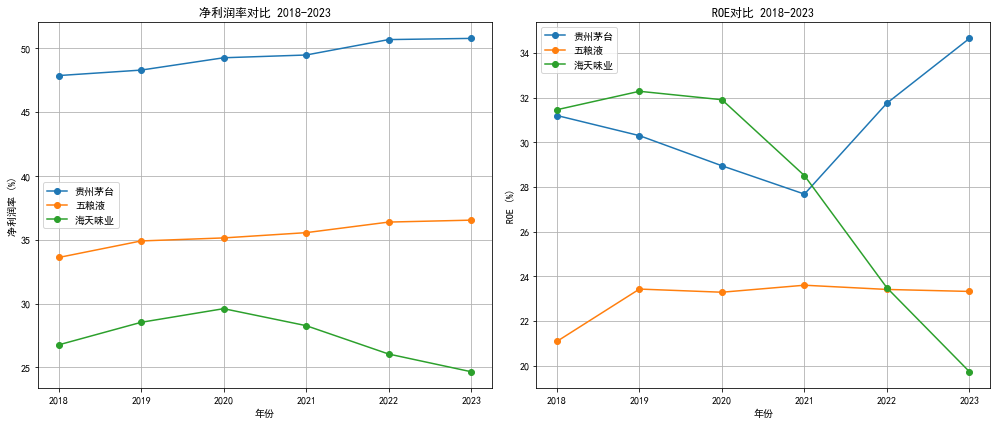

In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'SimHei'  # 支持中文
matplotlib.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 图1：净利润率趋势
for company in ['贵州茅台', '五粮液', '海天味业']:
    data = df[df['company'] == company]
    ax1.plot(data['year'], data['net_profit_margin'], marker='o', label=company)

ax1.set_title('净利润率对比 2018-2023')
ax1.set_xlabel('年份')
ax1.set_ylabel('净利润率 (%)')
ax1.legend()
ax1.grid(True)

# 图2：ROE趋势
for company in ['贵州茅台', '五粮液', '海天味业']:
    data = df[df['company'] == company]
    ax2.plot(data['year'], data['roe'], marker='o', label=company)

ax2.set_title('ROE对比 2018-2023')
ax2.set_xlabel('年份')
ax2.set_ylabel('ROE (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('profitability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

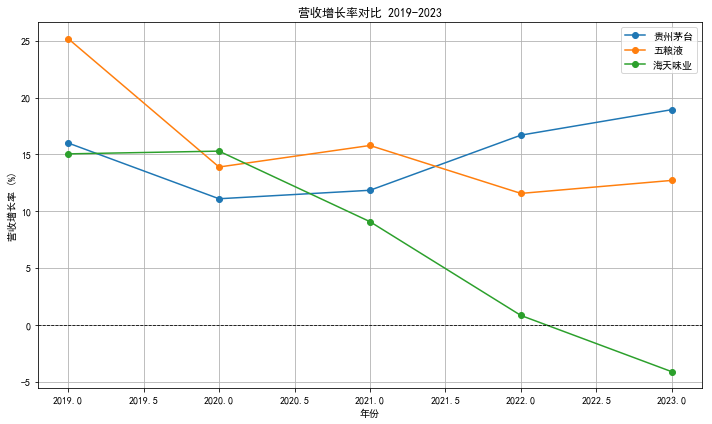

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for company in ['贵州茅台', '五粮液', '海天味业']:
    data = df[df['company'] == company].sort_values('year')
    growth = data['sale'].pct_change() * 100
    ax.plot(data['year'].iloc[1:], growth.iloc[1:], marker='o', label=company)

ax.set_title('营收增长率对比 2019-2023')
ax.set_xlabel('年份')
ax.set_ylabel('营收增长率 (%)')
ax.legend()
ax.grid(True)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('revenue_growth.png', dpi=150, bbox_inches='tight')
plt.show()